# Testing: Tennis EDA
Jupyter Notebook used to perform some EDA. This information are going to be used to develop different Python Modules used to make the Tennis Momentum Engine. 

#### 1. Setup & Imports

In [64]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.axes import Axes
import numpy as np
import pandas as pd
import seaborn as sns

PLOTS_PATH = "plots"
DATA_DIR = "../data"
MATCHES_CSV = os.path.join(DATA_DIR,"matches_data.csv")
PLAYERS_CSV = os.path.join(DATA_DIR,"players_data.csv")

DARK      = "#0D1117"   # Figure BACKGROUND
PANEL     = "#161B22"   # Axes BACKGROUND
GRID      = "#30363D"   # Grid LINES
TEXT      = "#E6EDF3"   # Primary LABELS 
SUBTEXT   = "#8B949E"   # Tick LABELS
CLAY      = "#C97B4B"
GRASS     = "#4CAF50"
HARD      = "#1E88E5"
CARPET    = "#9C27B0"
GOLD      = "#F0C040"
RED       = "#CF6679"
GREEN     = "#4CAF50"
BLUE      = "#1E88E5"
SURF_COLOR = {"Clay": CLAY, "Grass": GRASS, "Hard": HARD, "Carpet": CARPET}

In [65]:
plt.rcParams.update({
  "figure.facecolor":  DARK,
  "axes.facecolor":    PANEL,
  "axes.edgecolor":    GRID,
  "axes.labelcolor":   TEXT,
  "axes.titlecolor":   TEXT,
  "axes.titlesize":    12,
  "axes.labelsize":    10,
  "xtick.color":       SUBTEXT,
  "ytick.color":       SUBTEXT,
  "xtick.labelsize":   8,
  "ytick.labelsize":   8,
  "text.color":        TEXT,
  "grid.color":        GRID,
  "grid.linestyle":    "--",
  "grid.alpha":        0.45,
  "font.family":       "monospace",
  "axes.spines.top":   False,
  "axes.spines.right": False,
  "legend.framealpha": 0,
  "legend.labelcolor": TEXT,
  "legend.fontsize":   8,
})

In [66]:
mf = pd.read_csv(MATCHES_CSV, low_memory=False)
print(f"Loaded {len(mf):,} matches")
pp = pd.read_csv(PLAYERS_CSV, low_memory=False)
print(f"Loaded {len(pp):,} players")

Loaded 69,878 matches
Loaded 386 players


#### Plot (01): Comeback Overview

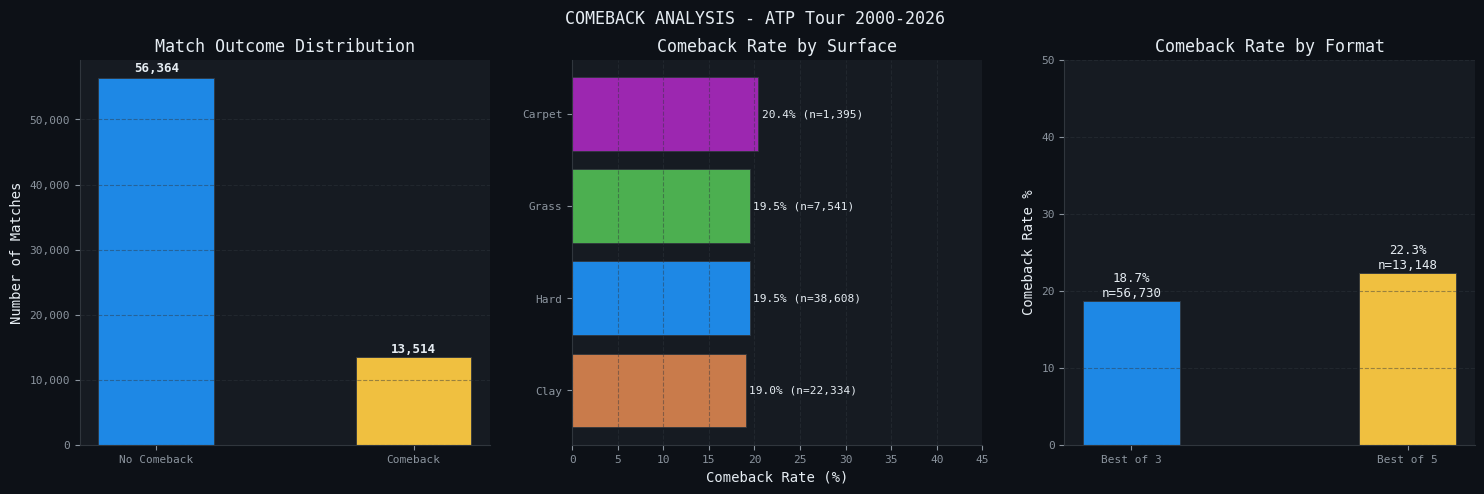

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle(f"COMEBACK ANALYSIS - ATP Tour 2000-2026")

 # Class Balance
ax: Axes = axes[0]
labels = ["No Comeback", "Comeback"]
counts = mf["came_back"].value_counts().sort_index().values
colors = [BLUE, GOLD]
bars = ax.bar(x=labels, height=counts, color=colors, width=0.45, edgecolor=GRID, linewidth=0.6)
for bar, val in zip(bars, counts):
  ax.text(x=bar.get_x() + bar.get_width() / 2,
          y=bar.get_height() * 1.01,
          s=f"{val:,}", ha="center", va="bottom", color=TEXT, fontsize=9, weight="bold")
ax.set_title("Match Outcome Distribution")
ax.set_ylabel("Number of Matches")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y")

# Comeback Rate by Surface
ax = axes[1]
surf_stats = (
  mf.groupby("surface")["came_back"]
  .agg(rate="mean", n="count")
  .reset_index()
  .sort_values("rate")
)
colors_s = [SURF_COLOR.get(s, SUBTEXT) for s in surf_stats["surface"]]
bars = ax.barh(surf_stats["surface"],surf_stats["rate"]*100, 
               color=colors_s, edgecolor=GRID,linewidth=0.6)
for bar, (_, row) in zip(bars, surf_stats.iterrows()):
  ax.text(x=bar.get_width() + 0.4,
          y=bar.get_y() + bar.get_height() / 2,
          s=f"{row["rate"]:.1%} (n={int(row["n"]):,})",
          va="center", color=TEXT, fontsize=8)
ax.set_title("Comeback Rate by Surface")
ax.set_xlabel("Comeback Rate (%)")
ax.set_xlim(0, 45)
ax.grid(axis="x")

# Comeback Rate by Best-of Format
ax = axes[2]
fmt_stats = (
  mf.groupby("best_of_5")["came_back"]
  .agg(rate="mean", n="count")
  .reset_index()
)
fmt_stats["labels"] = fmt_stats["best_of_5"].map({0: "Best of 3", 1: "Best of 5"})
bars = ax.bar(fmt_stats["labels"], fmt_stats["rate"]*100, color=[BLUE, GOLD], width=0.35, edgecolor=GRID, linewidth=0.6)
for bar, (_, row) in zip(bars, fmt_stats.iterrows()):
  ax.text(x=bar.get_x() + bar.get_width() / 2,
          y=bar.get_height() * 1.01,
          s=f"{row["rate"]:.1%}\nn={row["n"]:,}",
          ha="center", va="bottom", color=TEXT, fontsize=9)
ax.set_title("Comeback Rate by Format")
ax.set_ylabel("Comeback Rate %")
ax.set_ylim(0, 50)
ax.grid(axis="y")

#### Plot (02): Feature Distributions 

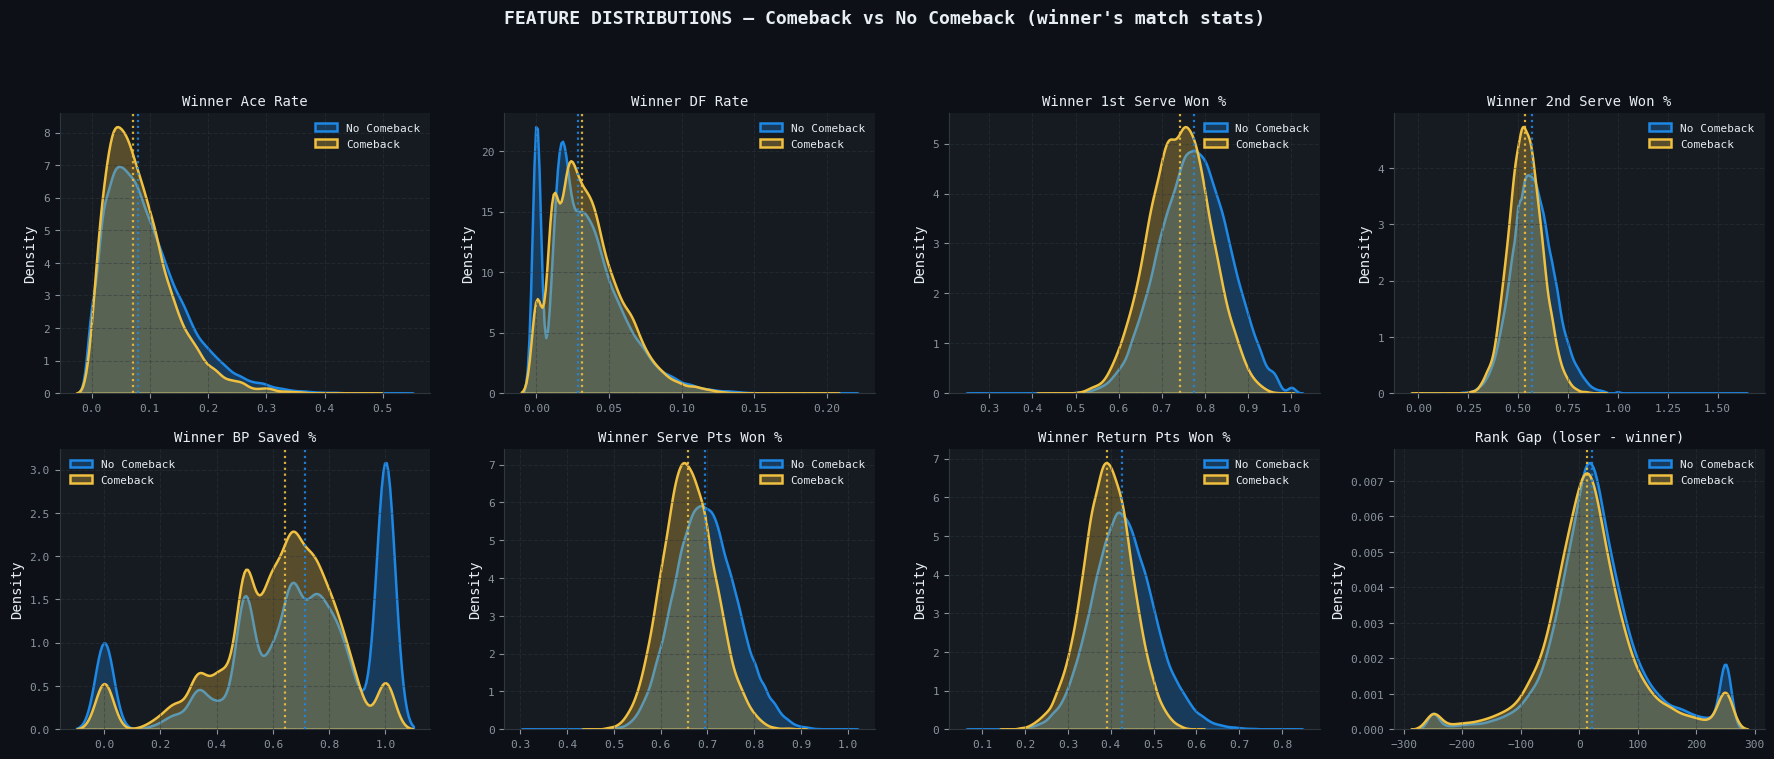

In [68]:
features = {
  "w_ace_rate": "Winner Ace Rate",
  "w_df_rate": "Winner DF Rate",
  "w_1stWon_pct": "Winner 1st Serve Won %",
  "w_2ndWon_pct": "Winner 2nd Serve Won %",
  "w_bpSaved_pct": "Winner BP Saved %",
  "w_srvWon_pct": "Winner Serve Pts Won %",
  "w_retWon_pct": "Winner Return Pts Won %",
  "rank_gap": "Rank Gap (loser - winner)",
}
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle("FEATURE DISTRIBUTIONS — Comeback vs No Comeback (winner's match stats)",
              fontsize=13, color=TEXT, weight="bold", y=1.01)
axes = axes.flatten()

grp0 = mf[mf["came_back"] == 0]
grp1 = mf[mf["came_back"] == 1]

for ax, (col, label) in zip(axes, features.items()):
  d0 = grp0[col].dropna()
  d1 = grp1[col].dropna()
  if col == "rank_gap":
    d0 = d0.clip(-250, 250) # came_back=0 points clipped
    d1 = d1.clip(-250, 250) # came_back=1 points clipped

  sns.kdeplot(data=d0, ax=ax, color=BLUE,  fill=True, alpha=0.30, label="No Comeback", linewidth=1.8)
  sns.kdeplot(data=d1, ax=ax, color=GOLD,  fill=True, alpha=0.30, label="Comeback", linewidth=1.8)

  for data, color in [(d0, BLUE), (d1, GOLD)]:
    ax.axvline(data.median(), color=color, linestyle=":", linewidth=1.6, alpha=0.9)

  ax.set_title(label, fontsize=10)
  ax.set_xlabel("")
  ax.legend()
  ax.grid(True)  

#### Plot (03): Features Correlation 

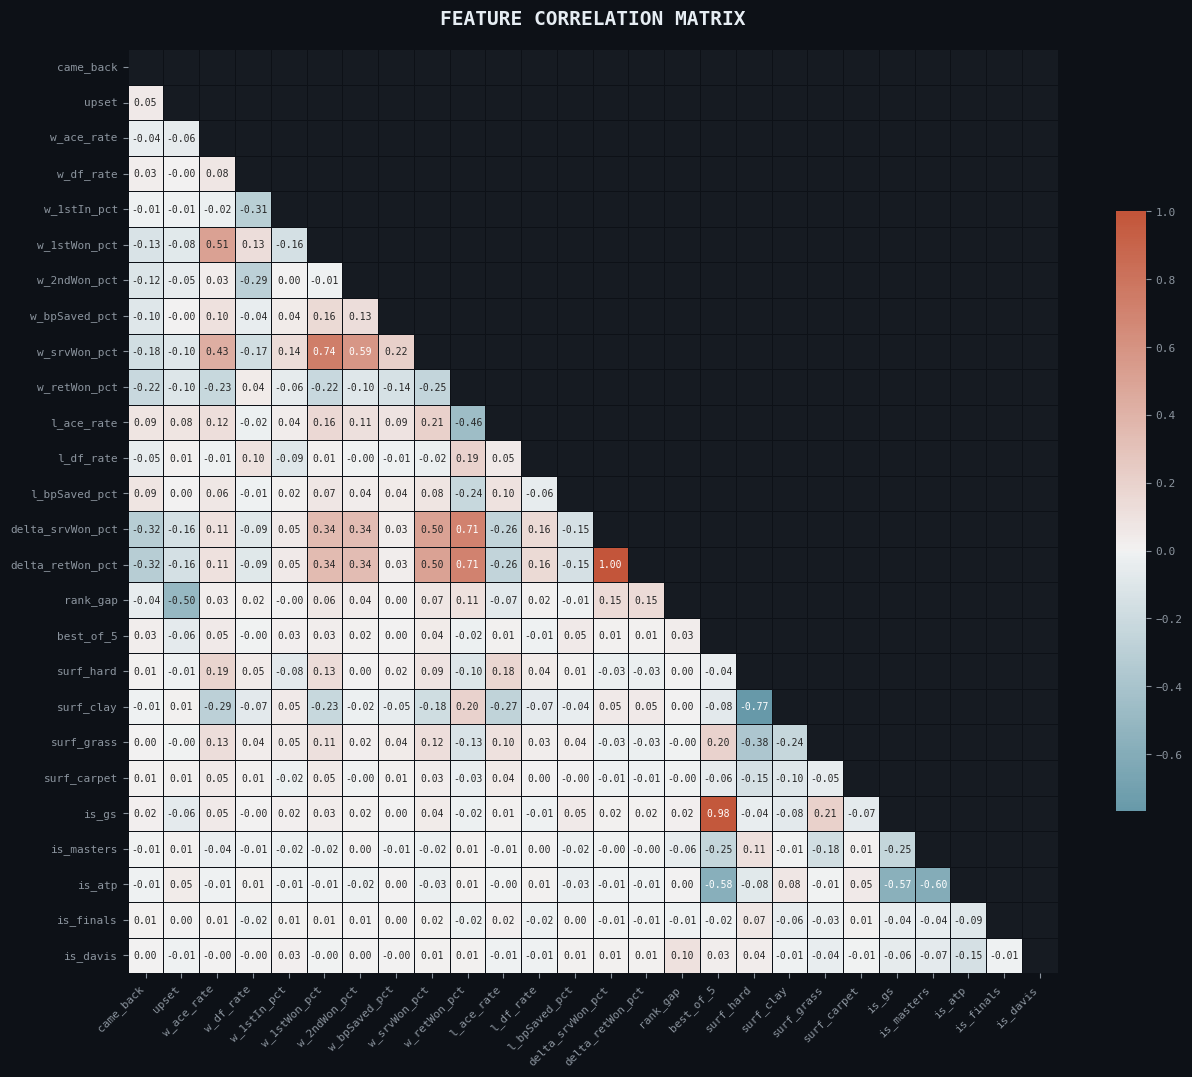

In [69]:
cols = [
  "came_back", "upset",
  "w_ace_rate", "w_df_rate", "w_1stIn_pct", "w_1stWon_pct",
  "w_2ndWon_pct",  "w_bpSaved_pct", "w_srvWon_pct", "w_retWon_pct",
  "l_ace_rate", "l_df_rate", "l_bpSaved_pct",
  "delta_srvWon_pct", "delta_retWon_pct", "rank_gap",
  "best_of_5",
  "surf_hard", "surf_clay", "surf_grass", "surf_carpet",
  "is_gs", "is_masters", "is_atp", "is_finals", "is_davis"
]
available = [c for c in cols if c in mf.columns]
mf_available = mf[available].dropna()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(mf_available.corr(), dtype=bool))
sns.heatmap(
  mf_available.corr(), mask=mask, annot=True, fmt=".2f",
  linewidths=0.4, linecolor=DARK,
  cmap=sns.diverging_palette(220, 20, as_cmap=True),
  center=0, ax=ax, annot_kws={"size": 7},
  cbar_kws={"shrink": 0.65},
)
ax.set_title("FEATURE CORRELATION MATRIX", fontsize=14, weight="bold", pad=18)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.show()

#### Plot (04): Upset Analysis 

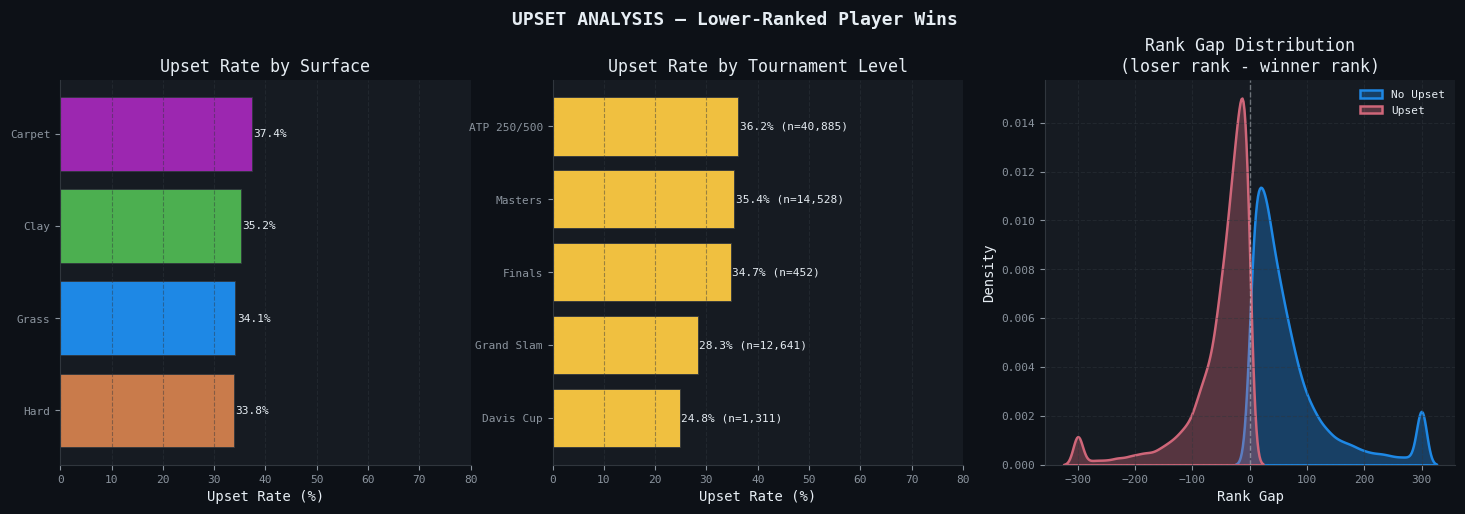

In [70]:
sub = mf.dropna(subset=["upset"]).copy()
lvl_map = {"G": "Grand Slam", "M": "Masters", "A": "ATP 250/500", "F": "Finals", "D": "Davis Cup"}
sub["level_label"] = sub["tourney_level"].map(lvl_map).fillna("Other")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UPSET ANALYSIS — Lower-Ranked Player Wins", fontsize=13, color=TEXT, 
             weight="bold", y=1.02)

# Upset Rate by Surface
ax = axes[0]
s = (sub.groupby("surface")["upset"]
     .agg(rate="mean", n="count")
     .reset_index().sort_values("rate"))
colors_s = [SURF_COLOR.get(s, SUBTEXT) for s in surf_stats["surface"]]
bars = ax.barh(s["surface"], s["rate"] * 100, color=colors_s, edgecolor=GRID, linewidth=0.6)
for bar, (_, row) in zip(bars, s.iterrows()):
  ax.text(x=bar.get_width() + 0.3,
          y=bar.get_y() + bar.get_height() / 2,
          s=f"{row["rate"]:.1%}",
          va="center", color=TEXT, fontsize=8)
ax.set_title("Upset Rate by Surface")
ax.set_xlabel("Upset Rate (%)")
ax.set_xlim(0, 80)
ax.grid(axis="x")

# Upset Rate by Tournament Level
ax = axes[1]
lv = (sub.groupby("level_label")["upset"]
      .agg(rate="mean", n="count")
      .reset_index()
      .query("n >= 100")
      .sort_values("rate"))
bars = ax.barh(lv["level_label"], lv["rate"] * 100, color=GOLD, edgecolor=GRID, linewidth=0.6)
for bar, (_, row) in zip(bars, lv.iterrows()):
    ax.text(x=bar.get_width() + 0.3, 
            y=bar.get_y() + bar.get_height() / 2,
            s=f"{row["rate"]:.1%} (n={int(row["n"]):,})",
            va="center", color=TEXT, fontsize=8)
ax.set_title("Upset Rate by Tournament Level")
ax.set_xlabel("Upset Rate (%)")
ax.set_xlim(0, 80)
ax.grid(axis="x")

# Rank gap KDE: upsets vs non-upsets
ax = axes[2]
u0 = sub[sub["upset"] == 0]["rank_gap"].dropna().clip(-300, 300)
u1 = sub[sub["upset"] == 1]["rank_gap"].dropna().clip(-300, 300)
sns.kdeplot(u0, ax=ax, color=BLUE, fill=True, alpha=0.35,
            label="No Upset", linewidth=1.8)
sns.kdeplot(u1, ax=ax, color=RED, fill=True, alpha=0.35,
            label="Upset", linewidth=1.8)
ax.axvline(0, color=TEXT, linestyle="--", linewidth=1, alpha=0.4)
ax.set_title("Rank Gap Distribution\n(loser rank - winner rank)")
ax.set_xlabel("Rank Gap")
ax.legend()
ax.grid(True)

clutch_index range: -1.742 → 1.988


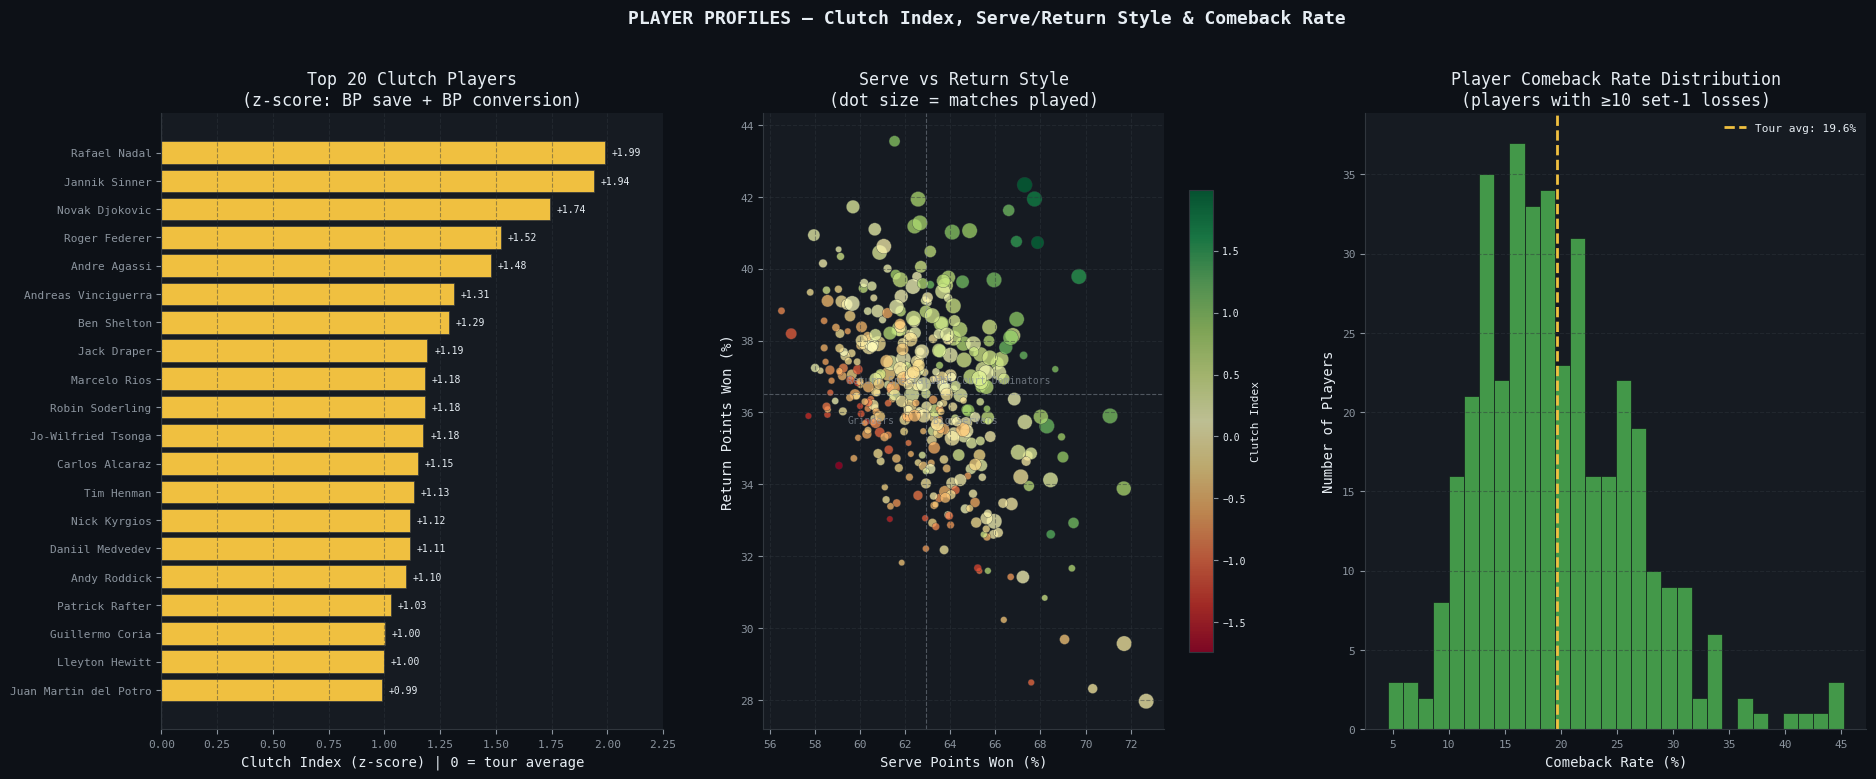

In [74]:
top_n = 20
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle("PLAYER PROFILES — Clutch Index, Serve/Return Style & Comeback Rate",
              fontsize=13, color=TEXT, weight="bold", y=1.01)


ci_min = pp["clutch_index"].min()
ci_max = pp["clutch_index"].max()
print(f"clutch_index range: {ci_min:.3f} → {ci_max:.3f}")
if ci_min > 0:
  print("WARNING: all clutch_index values are positive. Re-run feature_engineering.py")

# (a) Top-N clutch
ax = axes[0]
top = pp.nlargest(top_n, "clutch_index")[["player", "clutch_index"]].iloc[::-1]
bar_colors = [GOLD if v >= 0 else RED for v in top["clutch_index"]]
bars = ax.barh(top["player"], top["clutch_index"], color=bar_colors, 
                edgecolor=GRID, linewidth=0.5)
for bar, val in zip(bars, top["clutch_index"]):
  x_pos = val + 0.03 if val >= 0 else val - 0.03
  ha = "left" if val >= 0 else "right"
  ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
          f"{val:+.2f}", va="center", ha=ha, color=TEXT, fontsize=7)

ax.axvline(0, color=SUBTEXT, linestyle="--", linewidth=0.8)
ax.set_title(f"Top {top_n} Clutch Players\n(z-score: BP save + BP conversion)")
ax.set_xlabel("Clutch Index (z-score) | 0 = tour average")
ax.set_xlim(0,2.25)
ax.grid(axis="x")

# (b) Serve vs Return scatter
ax = axes[1]
sub = pp.dropna(subset=["srv_pts_won", "ret_pts_won", "clutch_index"])
sc = ax.scatter(
  sub["srv_pts_won"] * 100,
  sub["ret_pts_won"] * 100,
  c=sub["clutch_index"],
  cmap="RdYlGn",
  s=(sub["matches_played"].clip(40, 600) / 5),
  alpha=0.72,
  edgecolors=GRID,
  linewidths=0.3,
)
cb = plt.colorbar(sc, ax=ax, shrink=0.75)
cb.set_label("Clutch Index", color=TEXT, fontsize=8)
cb.ax.yaxis.set_tick_params(color=SUBTEXT, labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT)

mean_srv = sub["srv_pts_won"].mean() * 100
mean_ret = sub["ret_pts_won"].mean() * 100
ax.axvline(mean_srv, color=SUBTEXT, linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(mean_ret, color=SUBTEXT, linestyle="--", linewidth=0.8, alpha=0.5)

# Quadrant labels
offset = 0.3
ax.text(x=mean_srv + offset,
        y=mean_ret + offset,
        s="All-Court Dominators",
        color=SUBTEXT, fontsize=7, alpha=0.7)
ax.text(x=mean_srv - 3.5,
        y=mean_ret + offset,
        s="Return Specialists",
        color=SUBTEXT, fontsize=7, alpha=0.7)
ax.text(x=mean_srv + offset,
        y=mean_ret - 0.8,
        s="Big Servers",
        color=SUBTEXT, fontsize=7, alpha=0.7)
ax.text(x=mean_srv - 3.5,
        y=mean_ret - 0.8,
        s="Grinders",
        color=SUBTEXT, fontsize=7, alpha=0.7)

ax.set_xlabel("Serve Points Won (%)")
ax.set_ylabel("Return Points Won (%)")
ax.set_title("Serve vs Return Style\n(dot size = matches played)")
ax.grid(True)

# Comeback rate distribution
ax = axes[2]
sub2 = pp[(pp["cb_opportunities"] >= 10)].dropna(subset=["comeback_rate"])
mean_cb = sub2["comeback_rate"].mean()
ax.hist(sub2["comeback_rate"] * 100, bins=30,
        color=GRASS, edgecolor=DARK, alpha=0.85, linewidth=0.5)
ax.axvline(mean_cb * 100, color=GOLD, linestyle="--", linewidth=2,
            label=f"Tour avg: {mean_cb:.1%}")
ax.set_title("Player Comeback Rate Distribution\n(players with ≥10 set-1 losses)")
ax.set_xlabel("Comeback Rate (%)")
ax.set_ylabel("Number of Players")
ax.legend()
ax.grid(axis="y")

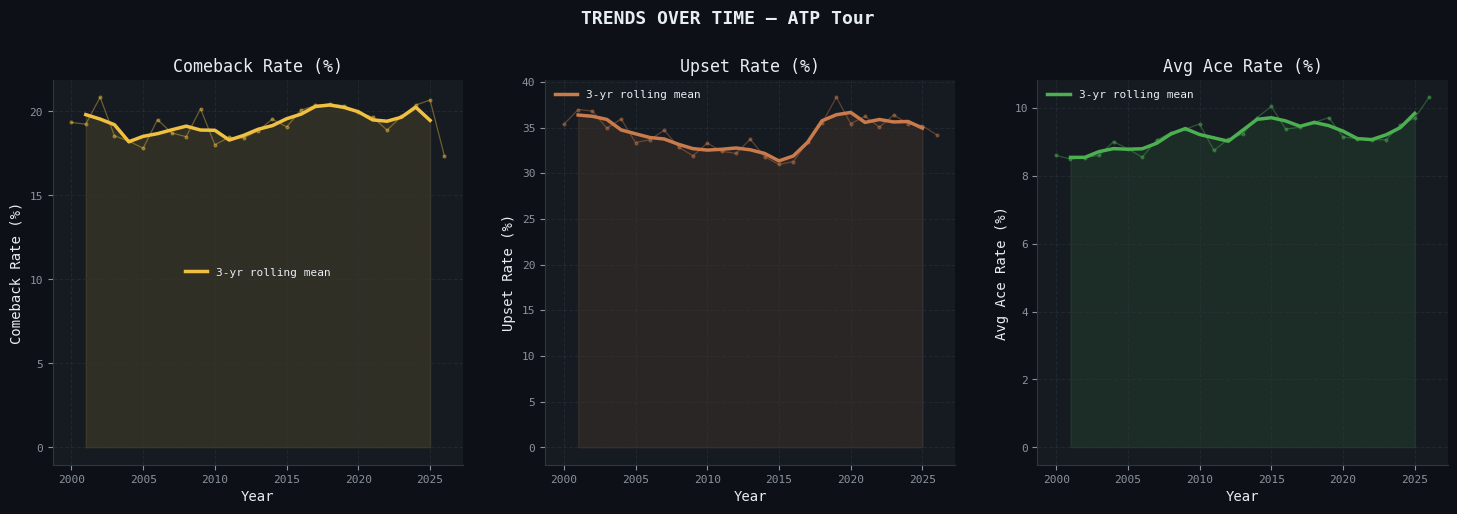

In [79]:
sub = mf.dropna(subset=["year"]).copy()
sub["year"] = sub["year"].astype(int)

yearly = sub.groupby("year").agg(
  comeback_rate = ("came_back", "mean"),
  upset_rate = ("upset", "mean"),
  ace_rate = ("w_ace_rate","mean"),
).reset_index()

# Rolling 3-year mean smoothing
for col in ["comeback_rate", "upset_rate", "ace_rate"]:
  yearly[f"{col}_roll"] = yearly[col].rolling(3, center=True).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("TRENDS OVER TIME — ATP Tour", fontsize=13, color=TEXT, weight="bold", y=1.02)

specs = [
  ("comeback_rate", GOLD, "Comeback Rate (%)"),
  ("upset_rate", CLAY, "Upset Rate (%)"),
  ("ace_rate", GRASS, "Avg Ace Rate (%)"),
]
for ax, (col, color, ylabel) in zip(axes, specs):
  ax.plot(yearly["year"], yearly[col] * 100,
          color=color, linewidth=0.9, alpha=0.4, marker="o", markersize=2)
  ax.plot(yearly["year"], yearly[f"{col}_roll"] * 100,
          color=color, linewidth=2.5, label="3-yr rolling mean")
  ax.fill_between(yearly["year"], yearly[f"{col}_roll"] * 100,
                  alpha=0.12, color=color)
  ax.set_title(ylabel)
  ax.set_xlabel("Year")
  ax.set_ylabel(ylabel)
  ax.legend(fontsize=8)
  ax.grid(True)